# Aumentación 3D con WGAN-GP

El dataset OASIS-1 tiene un desbalance de clases para la tarea de clasificar cerebros sanos vs cerebros con Very Mild Dementia. Para corregir este desbalance, se entrena un WGAN-GP 3D (Wasserstein GAN con gradient penalty) con los 70 cerebros reales de Very Mild Dementia. Una vez entrenado, el generador produce 246 cerebros sintéticos nuevos que se guardan como archivos .nii para usar en el entrenamiento del ResNet3D. El resultado final es un dataset balanceado de 316 sanos vs 316 Very Mild Dementia (70 reales + 246 sintéticos).

## Imports y configuraciones

In [1]:
import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
from scipy.ndimage import zoom
from dotenv import load_dotenv

In [ ]:
DATASET_ROOT = os.getenv("DATASET_ROOT")
TARGET_SHAPE = (64, 64, 64)
LATENT_DIM = 256
BETA = 0.0001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Carga de sujetos

Abrimos el archivo Excel con los metadatos del dataset y filtramos solo los sujetos con CDR = 0.5, que son los que tienen Very Mild Dementia. Luego buscamos el archivo de imagen de cada uno en todos los discos disponibles. Si algún sujeto aparece en el Excel pero no tiene archivo descargado, se omite con una advertencia.

In [4]:
xlsx_path = "oasis_cross-sectional-5708aa0a98d82080.xlsx"
df = pd.read_excel(xlsx_path)
very_mild = df[df["CDR"] == 0.5].copy()
DATASET_ROOT = os.getenv("DATASET_ROOT")
print(f"Sujetos CDR=0.5 en metadata: {len(very_mild)}")

base = os.path.dirname(DATASET_ROOT)  
DISC_ROOTS = []
for i in range(1, 13):
    disco = os.path.join(base, f"oasis_cross-sectional_disc{i}", f"disc{i}")
    if os.path.exists(disco):
        DISC_ROOTS.append(disco)

print(f"\nTotal discos disponibles: {len(DISC_ROOTS)}")
found_files      = []
missing_subjects = []

for _, row in very_mild.iterrows():
    sid = row["ID"]
    encontrado = False
    for root in DISC_ROOTS:
        pattern = os.path.join(
            root, sid,
            "PROCESSED", "MPRAGE", "T88_111",
            f"{sid}_mpr_n*_anon_111_t88_masked_gfc.hdr"
        )
        matches = glob.glob(pattern)
        if matches:
            found_files.append(matches[0])
            encontrado = True
            break
    if not encontrado:
        missing_subjects.append(sid)

print(f"Archivos encontrados en disco : {len(found_files)}")
print(f"Sujetos sin archivo : {len(missing_subjects)}")

Sujetos CDR=0.5 en metadata: 70

Total discos disponibles: 12
Archivos encontrados en disco : 70
Sujetos sin archivo : 0


## Preprocesamiento

Antes de entrenar el GAN, preparamos los 70 cerebros reales. Cada volumen viene con dimensiones 176×208×176 y escalas de brillo distintas entre sujetos, así que aplicamos dos pasos. Primero normalizamos las intensidades de cada cerebro por separado ignorando el fondo negro y luego lo reducimos a 64×64×64 para que el modelo pueda procesarlo sin consumir demasiada memoria. Al final mostramos tres cortes axiales para verificar que todo se cargó correctamente.


Tensor final : torch.Size([70, 1, 64, 64, 64])
Rango        : [-2.578, 7.374]


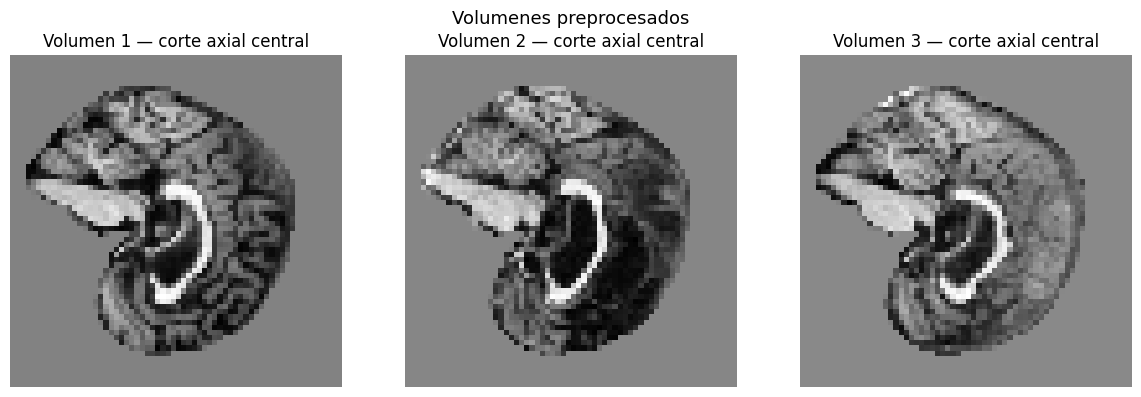

In [5]:
def load_and_preprocess(hdr_path):
    img = nib.load(hdr_path)
    data = np.squeeze(img.get_fdata()).astype(np.float32)
    
    if data.ndim != 3:
        raise ValueError(f"Shape inesperado después de squeeze: {data.shape} en {hdr_path}")
    
    mask = data > 0
    if mask.sum() > 0:
        data[mask] = (data[mask] - data[mask].mean()) / (data[mask].std() + 1e-8)
    
    factors = tuple(t / s for t, s in zip(TARGET_SHAPE, data.shape))
    return zoom(data, factors, order=1)

volumes = []
for i, path in enumerate(found_files):
    vol = load_and_preprocess(path)
    volumes.append(vol)

X = torch.tensor(np.stack(volumes), dtype=torch.float32).unsqueeze(1)
print(f"\nTensor final : {X.shape}")
print(f"Rango        : [{X.min():.3f}, {X.max():.3f}]")

n_show = min(3, len(volumes))
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
if n_show == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.imshow(X[i, 0, TARGET_SHAPE[0] // 2].numpy(), cmap="gray")
    ax.set_title(f"Volumen {i + 1} — corte axial central")
    ax.axis("off")
plt.suptitle("Volumenes preprocesados", fontsize=13)
plt.tight_layout()
plt.show()

## Arquitectura

Definimos la arquitectura del WGAN-GP, que tiene dos componentes que se entrenan juntos compitiendo entre sí:

* El Generador que toma un vector de ruido aleatorio de 256 números y lo expande progresivamente hasta producir un cerebro 3D de 64×64×64. Usa capas transpuestas de convolución 3D para ir aumentando el tamaño.

* El Critic que toma un cerebro, real o sintético, y produce un número que indica qué tan real parece. Usa capas de convolución 3D para ir reduciendo el tamaño hasta un solo valor.

El gradient penalt hace estable al WGAN-GP al penaliza al critic si sus gradientes se alejan demasiado de 1, evitando que se vuelva demasiado poderoso y que el generador no pueda mejorar.

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4 * 4)
        self.net = nn.Sequential(
            nn.ConvTranspose3d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose3d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose3d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),

            nn.ConvTranspose3d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 256, 4, 4, 4)
        return self.net(x)


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(1, 32,  kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv3d(32, 64,  kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv3d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv3d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.fc = nn.Linear(256 * 4 * 4 * 4, 1)

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


def gradient_penalty(critic, real, fake, device):
    batch_size = real.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, 1, device=device)
    interpolated = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    score = critic(interpolated)
    gradients = torch.autograd.grad(
        outputs=score,
        inputs=interpolated,
        grad_outputs=torch.ones_like(score),
        create_graph=True,
        retain_graph=True
    )[0]
    gradients = gradients.view(batch_size, -1)
    penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return penalty


# Verificar con forward pass de prueba
G_test = Generator(LATENT_DIM)
C_test = Critic()
z_test = torch.randn(1, LATENT_DIM)
fake_test = G_test(z_test)
score_test = C_test(fake_test)
print(f"Generator output shape : {fake_test.shape}")
print(f"Critic output shape    : {score_test.shape}")
del G_test, C_test, z_test, fake_test, score_test
print("Arquitectura WGAN-GP lista.")

Generator output shape : torch.Size([1, 1, 64, 64, 64])
Critic output shape    : torch.Size([1, 1])
Arquitectura WGAN-GP lista.


## Entrenamiento

Entrenamos el WGAN-GP durante 500 épocas. La dinámica es la siguiente: por cada vez que se actualiza el generador, el critic se actualiza 5 veces. Esto le da ventaja al critic para que pueda dar señales útiles al generador sobre cómo mejorar. En un WGAN-GP los valores de loss son negativos y eso es completamente normal. Lo que indica que el entrenamiento va bien es que ambas curvas se estabilicen, no que lleguen a cero. Al terminar se guardan los pesos de ambos modelos.

Iniciando entrenamiento WGAN-GP
Épocas: 500 | Batch: 4 | N_critic: 5 | Lambda GP: 10
-------------------------------------------------------


c:\Users\sebas\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Época  10/500 | Loss C:  -791.37 | Loss G:  -233.47
Época  20/500 | Loss C:  -504.26 | Loss G:  -322.45
Época  30/500 | Loss C:  -379.43 | Loss G:  -345.80
Época  40/500 | Loss C:  -325.16 | Loss G:  -332.49
Época  50/500 | Loss C:  -286.26 | Loss G:  -321.36
Época  60/500 | Loss C:  -272.12 | Loss G:  -324.04
Época  70/500 | Loss C:  -251.23 | Loss G:  -333.82
Época  80/500 | Loss C:  -241.04 | Loss G:  -342.09
Época  90/500 | Loss C:  -230.77 | Loss G:  -346.33
Época 100/500 | Loss C:  -228.69 | Loss G:  -356.91
Época 110/500 | Loss C:  -223.47 | Loss G:  -358.54
Época 120/500 | Loss C:  -219.93 | Loss G:  -357.78
Época 130/500 | Loss C:  -225.26 | Loss G:  -366.17
Época 140/500 | Loss C:  -220.21 | Loss G:  -366.07
Época 150/500 | Loss C:  -224.92 | Loss G:  -363.27
Época 160/500 | Loss C:  -222.58 | Loss G:  -370.06
Época 170/500 | Loss C:  -225.41 | Loss G:  -363.44
Época 180/500 | Loss C:  -229.81 | Loss G:  -367.19
Época 190/500 | Loss C:  -233.40 | Loss G:  -372.48
Época 200/50

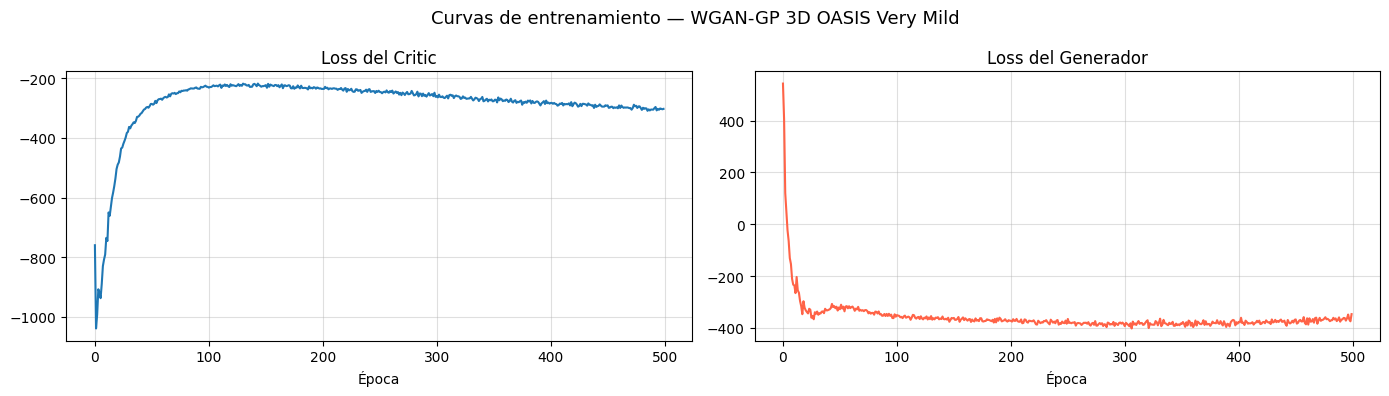

Modelos guardados: wgan_generator_very_mild.pth / wgan_critic_very_mild.pth


In [7]:
# Hiperparámetros
NUM_EPOCHS = 500
LAMBDA_GP = 10
N_CRITIC = 5
BATCH_SIZE = 4 if device.type == "cuda" else 1
LR_G = 1e-4
LR_C = 1e-4

loader = DataLoader(
    TensorDataset(X),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

G = Generator(LATENT_DIM).to(device)
C = Critic().to(device)

opt_G = torch.optim.Adam(G.parameters(), lr=LR_G, betas=(0.0, 0.9))
opt_C = torch.optim.Adam(C.parameters(), lr=LR_C, betas=(0.0, 0.9))

print(f"Iniciando entrenamiento WGAN-GP")
print(f"Épocas: {NUM_EPOCHS} | Batch: {BATCH_SIZE} | N_critic: {N_CRITIC} | Lambda GP: {LAMBDA_GP}")
print("-" * 55)

losses_G = []
losses_C = []

for epoch in range(1, NUM_EPOCHS + 1):
    G.train()
    C.train()
    epoch_loss_C = 0.0
    epoch_loss_G = 0.0
    n_batches    = 0

    for (real,) in loader:
        real = real.to(device)
        cur_batch = real.size(0)

        # Entrenar critic N_CRITIC veces por cada vez que se entrena el generador
        for _ in range(N_CRITIC):
            z    = torch.randn(cur_batch, LATENT_DIM, device=device)
            fake = G(z).detach()
            gp   = gradient_penalty(C, real, fake, device)
            loss_C = -C(real).mean() + C(fake).mean() + LAMBDA_GP * gp
            opt_C.zero_grad()
            loss_C.backward()
            opt_C.step()

        # Entrenar generador
        z      = torch.randn(cur_batch, LATENT_DIM, device=device)
        fake   = G(z)
        loss_G = -C(fake).mean()
        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        epoch_loss_C += loss_C.item()
        epoch_loss_G += loss_G.item()
        n_batches    += 1

    avg_C = epoch_loss_C / n_batches
    avg_G = epoch_loss_G / n_batches
    losses_C.append(avg_C)
    losses_G.append(avg_G)

    if epoch % 10 == 0:
        print(f"Época {epoch:3d}/{NUM_EPOCHS} | Loss C: {avg_C:8.2f} | Loss G: {avg_G:8.2f}")

print("-" * 55)
print("Entrenamiento finalizado.")

# Curva de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(losses_C, linewidth=1.5)
ax1.set_title("Loss del Critic")
ax1.set_xlabel("Época")
ax1.grid(True, alpha=0.4)

ax2.plot(losses_G, linewidth=1.5, color="tomato")
ax2.set_title("Loss del Generador")
ax2.set_xlabel("Época")
ax2.grid(True, alpha=0.4)

plt.suptitle("Curvas de entrenamiento — WGAN-GP 3D OASIS Very Mild", fontsize=13)
plt.tight_layout()
plt.show()

torch.save(G.state_dict(), "wgan_generator_very_mild.pth")
torch.save(C.state_dict(), "wgan_critic_very_mild.pth")
print("Modelos guardados: wgan_generator_very_mild.pth / wgan_critic_very_mild.pth")

## Generación

Con el generador ya entrenado, producimos los 246 cerebros sintéticos que necesitamos para balancear el dataset. Para esto inventamos un vector de 256 números aleatorios, se lo pasamos al generador, y él produce un cerebro 3D completo. Cada cerebro generado se guarda como un archivo .nii en una carpeta separada.

Very Mild reales     : 70
Volúmenes a generar  : 246
Directorio de salida : C:\Users\sebas\OneDrive\Documentos\Octavo_semestre\Imagenes y vision\synthetic_very_mild_3D

246 volúmenes .nii guardados en:
  C:\Users\sebas\OneDrive\Documentos\Octavo_semestre\Imagenes y vision\synthetic_very_mild_3D



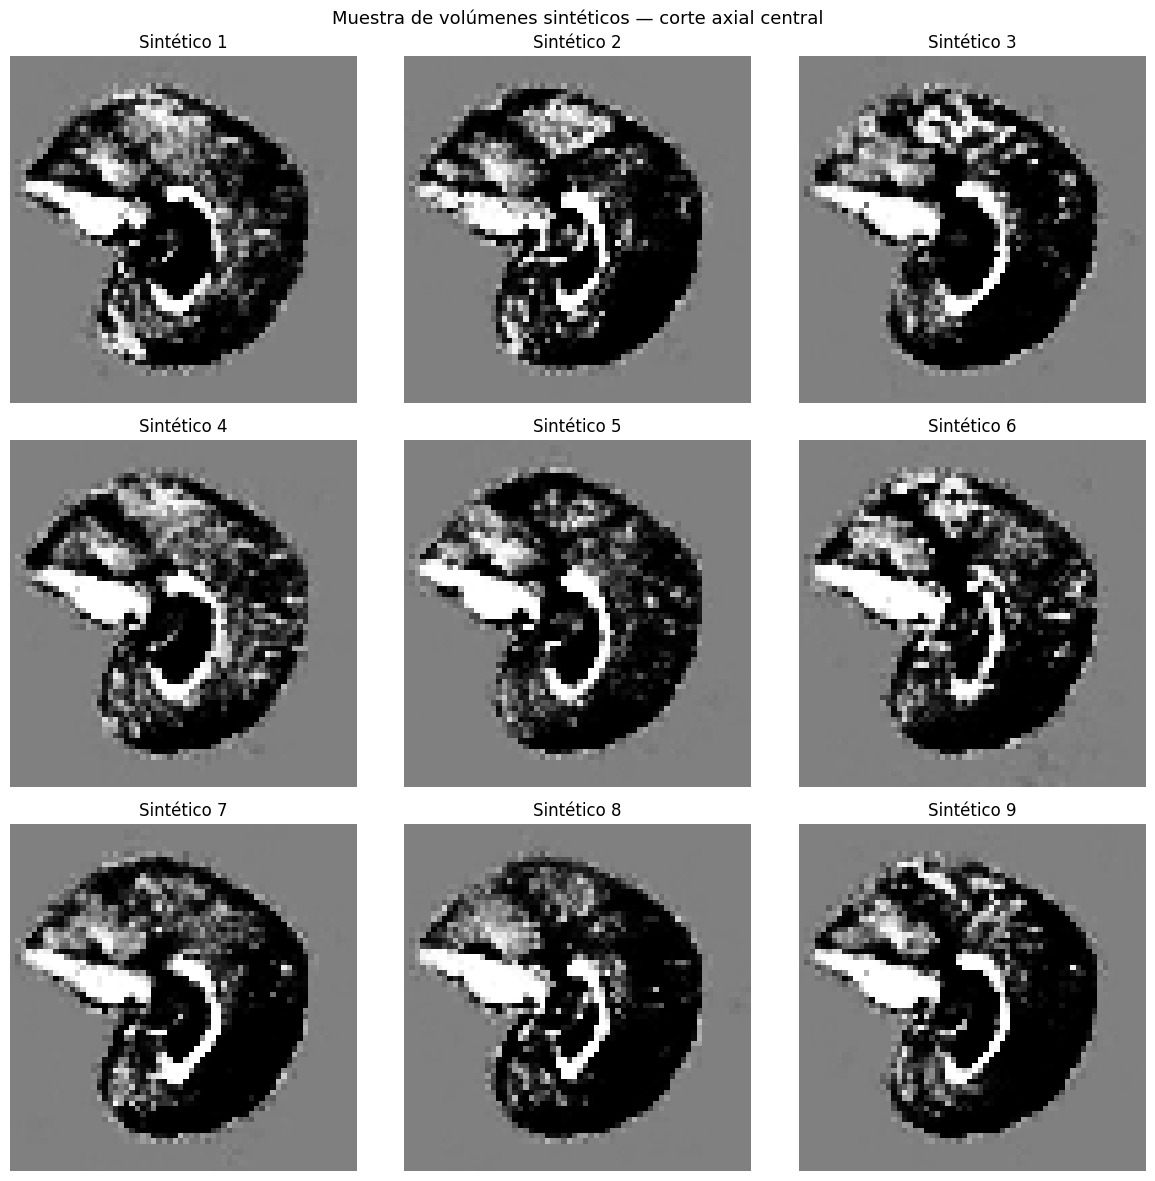

In [8]:
n_very_mild_real = len(found_files)
n_synthetic = 316 - n_very_mild_real
base_proyecto = os.path.dirname(os.path.dirname(DATASET_ROOT))
output_dir = os.path.join(base_proyecto, "synthetic_very_mild_3D")
os.makedirs(output_dir, exist_ok=True)

print(f"Very Mild reales     : {n_very_mild_real}")
print(f"Volúmenes a generar  : {n_synthetic}")
print(f"Directorio de salida : {output_dir}")
print()

G.eval()
synthetic_volumes = []
with torch.no_grad():
    for i in range(n_synthetic):
        z   = torch.randn(1, LATENT_DIM, device=device)
        vol = G(z).squeeze().cpu().numpy()
        synthetic_volumes.append(vol)
        out_path = os.path.join(output_dir, f"synthetic_very_mild_{i:04d}.nii")
        nib.save(nib.Nifti1Image(vol, np.eye(4)), out_path)

print(f"{n_synthetic} volúmenes .nii guardados en:\n  {output_dir}")
print()

n_grid = min(9, len(synthetic_volumes))
cols = 3
rows = (n_grid + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes_flat = np.array(axes).flatten()

for idx in range(len(axes_flat)):
    ax = axes_flat[idx]
    if idx < n_grid:
        corte = synthetic_volumes[idx][TARGET_SHAPE[0] // 2]
        ax.imshow(corte, cmap="gray")
        ax.set_title(f"Sintético {idx + 1}")
    ax.axis("off")

plt.suptitle("Muestra de volúmenes sintéticos — corte axial central", fontsize=13)
plt.tight_layout()
plt.show()

## Verificación

Comparamos las distribuciones de intensidad entre los cerebros reales y los sintéticos. Si los histogramas se solapan bien significa que el generador aprendió correctamente cómo se ven los cerebros con Very Mild Dementia. Al final mostramos el balance de clases resultante del dataset completo.

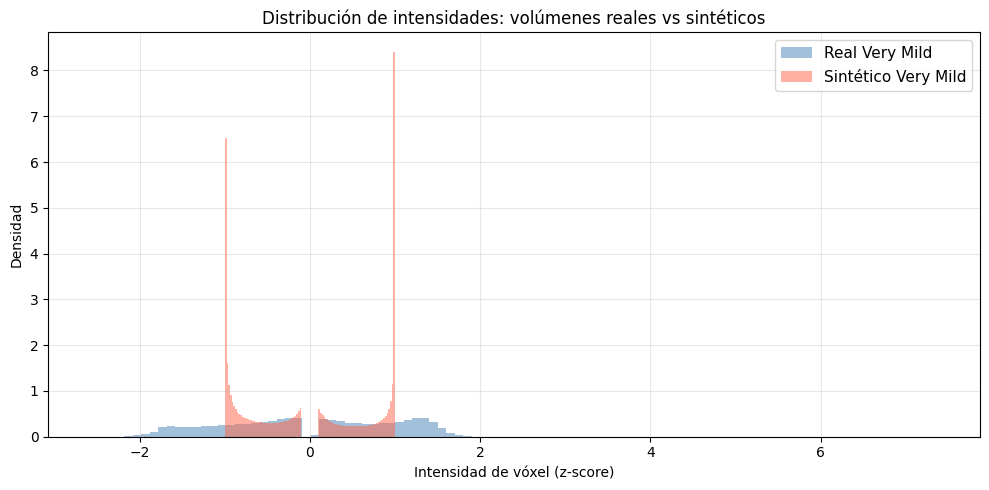

Distribucion final de clases
 Sanos (CDR=0.0) :  316
 Very Mild real (CDR=0.5) :   70
 Very Mild sintetico :  246
 Very Mild total :  316
 Balance sanos/very_mild : 316/316


In [9]:
umbral = 0.1
real_vals = X.numpy()[np.abs(X.numpy()) > umbral].ravel()
synt_vals = np.concatenate([
    v[np.abs(v) > umbral].ravel() for v in synthetic_volumes
])

plt.figure(figsize=(10, 5))
plt.hist(real_vals, bins=100, alpha=0.5, label="Real Very Mild", color="steelblue", density=True)
plt.hist(synt_vals, bins=100, alpha=0.5, label="Sintético Very Mild", color="tomato", density=True)
plt.xlabel("Intensidad de vóxel (z-score)")
plt.ylabel("Densidad")
plt.title("Distribución de intensidades: volúmenes reales vs sintéticos")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_healthy = 316
n_vm_real = n_very_mild_real
n_vm_synthetic = n_synthetic
n_vm_total = n_vm_real + n_vm_synthetic

print("=" * 50)
print("Distribucion final de clases")
print("=" * 50)
print(f" Sanos (CDR=0.0) : {n_healthy:4d}")
print(f" Very Mild real (CDR=0.5) : {n_vm_real:4d}")
print(f" Very Mild sintetico : {n_vm_synthetic:4d}")
print(f" Very Mild total : {n_vm_total:4d}")
print("=" * 50)
print(f" Balance sanos/very_mild : {n_healthy}/{n_vm_total}")